# Przykład

## Prosty przykład

$$
s = 2 \\
e = 1 \\
h = 2 \\
p = 4
$$

$$
L =
\begin{aligned}
&(51.103504, 17.086370),\ (51.100217, 17.082551),\\
&(51.100390, 17.099490)
\end{aligned}
$$

$$
M =
\begin{aligned}
&(51.103910, 17.086310),\ (51.105504, 17.186370)
\end{aligned}
$$

$$
f_{n} =
\begin{aligned}
&100,\ 155
\end{aligned}
$$

$$
r_{i,n} =
\begin{aligned}
&45.31,\ 7000, \\
&488,\ 7300, \\
&1000,\ 6100
\end{aligned}
$$

$$
v_{i} =
\begin{aligned}
&2,\ 1,\ 1
\end{aligned}
$$

$$
c_{i} =
\begin{aligned}
&2,\ 4,\ 0
\end{aligned}
$$

$$
d = 3000
$$

## Funkcja Celu
Dla tego przykładu funkcja celu:
$$
\min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in}  \right)
$$

Gdybyśmy zapomnieli o naszych ograniczeniach to macierz Q by wyglądała teraz tak wiedząc że
zmienne liniowe możemy zapisać jako kwadratowe
$$
x_j = x_j^2
$$

wzór qubo:
$$
\min y = x^T Q x
$$
Q =
|       | x₁₁   | x₁₂   | x₂₁   | x₂₂   | x₃₁   | x₃₂   |
|-------|--------|--------|--------|--------|--------|--------|
| x₁₁  | 47.31  | 0      | 0      | 0      | 0      | 0      |
| x₁₂  | 0      | 7002   | 0      | 0      | 0      | 0      |
| x₂₁  | 0      | 0      | 492    | 0      | 0      | 0      |
| x₂₂  | 0      | 0      | 0      | 4304      | 0   | 0      |
| x₃₁  | 0      | 0      | 0      | 0      | 1000      | 0   |
| x₃₂  | 0      | 0      | 0      | 0      | 0      | 6100   |









## Ograniczenia
W problemie występują dane ograniczenia

$$
\sum_{i \in L}  x_{i,n} = 1 \quad \forall n \in M
$$

$$
 \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L
$$


Aby przekształcić ogranicznia możemy skorzystać z przekształceń w kary które wyglądają tak:
| Klasyczne Ograniczenie          | Odpowiadająca kara                          |
|-------------------------------|---------------------------------------------|
|  x + y <= 1             | P(xy)                                  |
|  x + y >= 1             |  P(1 - x - y + xy)                      |
|  x + y = 1               |  P(1 - x - y + 2xy)                     |
| x <= y               |  P(x - xy)                            |
|  x_1 + x_2 + x_3 <= 1  | P(x_1x_2 + x_1x_3 + x_2x_3)           |
|  x = y                   | P(x + y - 2xy)                         |

Zaś jeśli są nierówności to możemy skorzystać z tzw. *slack variables*:

Przykład z nimi:

$$
3x_0 + 11x_1 + 14x_2 + 19x_3 + 5x_4 \le 26
$$

$$
3x_0 + 11x_1 + 14x_2 + 19x_3 + 5x_4 + S_1 = 26 \tag{4}
$$

gdzie:
$$
S = \sum_{k=0}^{N-1} 2^k s_k,
$$

$$
N = \lfloor\log_2(\max S)\rfloor + 1.
$$


czyli:
$$
S_1 = 2^0 s_{01} + 2^1 s_{11} + 2^2 s_{21} + 2^3 s_{31} + 2^4 s_{41}
$$

Funkcja karna:
$$
p(x,s) = \lambda \left(3x_0 + 11x_1 + 14x_2 + 19 x_3 + 5x_4 + x_5 + 2 x_6 + 4x_7 + 8 x_8 + 16 x_9 - 26\right)^2 \tag{5}
$$


### A więc dla ograniczenia #1:
$$ \sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M $$
- Każdy obiekt $n$ musi być przypisany do dokładnie jednego schronu $i$

Które możemy rozpisać jako:
$$ x_{11} + x_{21} + x_{31} = 1 $$
$$ x_{12} + x_{22} + x_{32} = 1 $$

Zapisujemy jako karę: (czemu akurat taka kara ? sprawdź strona 28 dokument QUBO)
$$ P_1*(x_{11} + x_{21} + x_{31} - 1)^2 + P_1*(x_{12} + x_{22} + x_{32} - 1)^2 $$




### Ograniczenie #2:
$$
\sum_{n \in M} x_{in} \leq v_i \quad \forall i \in L
$$
- Schron $i$ może obsłużyć tylko tyle obiektów mieszkalnych $n$ ile wynosi jego pojemność $v_{i}$

Które możemy rozpisać jako:
$$
(x_{11} + x_{12}) \leq 2
$$

$$
(x_{21}  + x_{22}) \leq 1
$$

$$
(x_{31} + x_{32}) \leq 1
$$
Stosujemy slack variable i zapisujemy:
$$
    (x_{11} + x_{12}  + S_{1}) = 2
$$
$$
    (x_{21} + x_{22} + S_{2}) = 1
$$
$$
    (x_{31} + x_{32} + S_{3}) = 1
$$
gdzie dla każdego S:
$$
S = \sum_{k=0}^{N-1} 2^k s_k,
$$
$$Dla S_{1} N=2  $$
$$ S_{1}:
P_2*(x_{11} + x_{12} + s_{10} + 2*s_{11}  - 2)^2
$$







## Zapisanie Qubo Python


## przykładowe dane

In [22]:
import pandas as pd
from geopy.distance import geodesic # do obliczenia odległości
import numpy as np
import math

s = 2 # dostępne lokalizacje nowe
e = 1 # istniejace juz schrony
h = 2 # liczba obiektów mieszkalnych

d = 3000 # Maksymalna dozwolona odległość, póki co nie wykorzystywana

P = [20, 20]  # kara (do dostosowania póki co losowe)

p = 4 # budżet na schrony
v = [2, 1, 1] # Pojemność schronu i

slack_sizes = [math.floor(math.log2(vi))  for vi in v] # za pojemności schronów
slack_sizes.append(math.floor(math.log2(p)) ) # za budżet

# Lokalizacje schrony i
L = [[51.103504, 17.086370],
    [51.100217, 17.082551],
    [51.100390, 17.099490]]

# Lokalizacje obiekty mieszkalne n
M = [[51.103910, 17.086310],
    [51.105504, 17.186370]]

# Odległości r_{i,n} w kilometrach
r = [[geodesic(l, m).kilometers for m in M] for l in L]
r = np.array(r)

# Zmienna decyzyjna jeśli schron
x = [[1 for _ in range(h)] for _ in range(s + e)]

# Inicjalizacja QUBO - bierzemy pod uwagę już zmiennę typu slack
N = (s + e) * h  + sum(slack_sizes)
Q = np.zeros((N, N))

def idx(i, n):
    return i * h + n
Q

array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Funkcja celu: $$ \min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in} \right) $$

In [23]:
for i in range(s + e):
    for n in range(h):
        cost = r[i][n]
        Q[idx(i, n), idx(i, n)] += cost
Q

array([[0.04536269, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 7.00751965, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.48797431, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 7.29547536, 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 1.0027953 ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        6.11180586, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],


Ograniczenia:
$$
\sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M
$$

In [24]:
for n in range(h):
    terms = [(idx(i, n), 1) for i in range(s + e)]

    for a, wa in terms:
        Q[a, a] += P[0] * wa**2 - 2 * P[0] * wa
    for i in range(len(terms)):
        for j in range(i + 1, len(terms)):
            a, wa = terms[i]
            b, wb = terms[j]
            value = 2* P[0] * wa * wb
            Q[a, b] += value / 2
            Q[b, a] += value / 2
Q

array([[-19.95463731,   0.        ,  20.        ,   0.        ,
         20.        ,   0.        ,   0.        ,   0.        ,
          0.        ],
       [  0.        , -12.99248035,   0.        ,  20.        ,
          0.        ,  20.        ,   0.        ,   0.        ,
          0.        ],
       [ 20.        ,   0.        , -19.51202569,   0.        ,
         20.        ,   0.        ,   0.        ,   0.        ,
          0.        ],
       [  0.        ,  20.        ,   0.        , -12.70452464,
          0.        ,  20.        ,   0.        ,   0.        ,
          0.        ],
       [ 20.        ,   0.        ,  20.        ,   0.        ,
        -18.9972047 ,   0.        ,   0.        ,   0.        ,
          0.        ],
       [  0.        ,  20.        ,   0.        ,  20.        ,
          0.        , -13.88819414,   0.        ,   0.        ,
          0.        ],
       [  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.    

$$
 \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L
$$

In [25]:
slack_offset = (s + e) * h

for i in range(s + e):
    N_i = math.floor(math.log2(v[i])) + 1
    slack_idxs = [slack_offset + sum(slack_sizes[:i]) + k for k in range(N_i)]

    x_terms = [(idx(i, n), 1) for n in range(h)]
    s_terms = [(s_idx, 2**k) for k, s_idx in enumerate(slack_idxs)]

    terms = x_terms + s_terms
    rhs = v[i]

    for a, wa in terms:
        Q[a, a] += P[1] * (wa ** 2) - 2 * P[1] * rhs * wa
        for b, wb in terms:
            if a < b:
                Q[a, b] += P[1] * wa * wb
                Q[b, a] += P[1] * wa * wb
Q

array([[ -79.95463731,   20.        ,   20.        ,    0.        ,
          20.        ,    0.        ,   20.        ,   40.        ,
           0.        ],
       [  20.        ,  -72.99248035,    0.        ,   20.        ,
           0.        ,   20.        ,   20.        ,   40.        ,
           0.        ],
       [  20.        ,    0.        ,  -39.51202569,   20.        ,
          20.        ,    0.        ,    0.        ,   20.        ,
           0.        ],
       [   0.        ,   20.        ,   20.        ,  -32.70452464,
           0.        ,   20.        ,    0.        ,   20.        ,
           0.        ],
       [  20.        ,    0.        ,   20.        ,    0.        ,
         -38.9972047 ,   20.        ,    0.        ,   20.        ,
           0.        ],
       [   0.        ,   20.        ,    0.        ,   20.        ,
          20.        ,  -33.88819414,    0.        ,   20.        ,
           0.        ],
       [  20.        ,   20.        ,   

## Wpisanie do sieci grafowej

## Budowa grafu

In [26]:
import torch
from torch_geometric.data import Data
import numpy as np

Q_sparse = (Q != 0)
rows, cols = np.where(Q_sparse)

edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
edge_attr = torch.tensor(Q[rows, cols], dtype=torch.float)

x = torch.ones((N, 1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [27]:
data

Data(x=[9, 1], edge_index=[2, 44], edge_attr=[44])

### Jak to wygląda ?

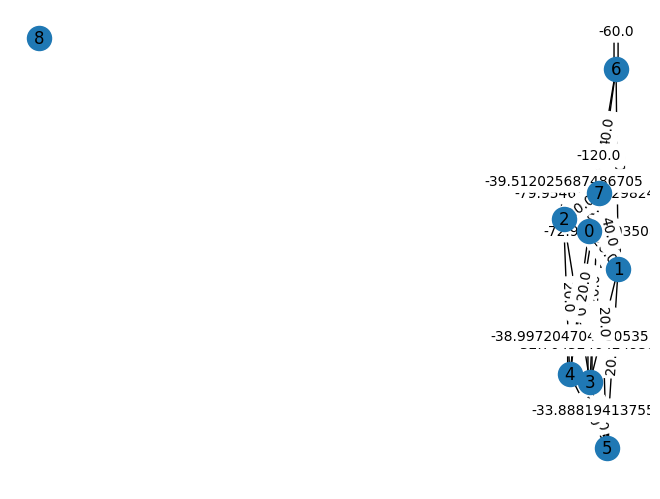

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(range(N))
rows, cols = np.where(Q_sparse)
for i, j in zip(rows, cols):
    G.add_edge(i, j, weight=Q[i, j])


pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=300)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch.optim import Adam

class QUBOGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.01):
        super(QUBOGCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        return torch.sigmoid(x).squeeze()

In [30]:
def qubo_loss(probs, Q):
    probs = probs.view(-1, 1)  # (N, 1)
    Q = Q.detach().float().to(probs.device)
    return (probs.T @ Q @ probs).squeeze()

In [31]:
def train_qubo_gnn(data, Q, model, optimizer, epochs=1000, tol=1e-4, patience=10000, threshold=0.5):
    best_loss = float('inf')
    best_solution = None
    wait = 0

    if not isinstance(Q, torch.Tensor):
        Q = torch.tensor(Q, dtype=torch.float32)
    Q = Q.detach().to(model.parameters().__next__().device)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        probs = model(data)
        loss = qubo_loss(probs, Q)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

        # Early stopping
        if loss.item() + tol < best_loss:
            best_loss = loss.item()
            best_solution = (probs >= threshold).float().detach()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    return best_solution, best_loss

In [32]:
in_channels = 1
hidden_channels = 16
out_channels = 1
dropout = 0.01
learning_rate = 1e-3
epochs = 5000
tolerance = 1e-4
patience = 1000
threshold = 0.8

model = QUBOGCN(in_channels, hidden_channels, out_channels, dropout)
model = model.to(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# trening
best_solution, best_loss = train_qubo_gnn(
    data=data,
    Q=Q,
    model=model,
    optimizer=optimizer,
    epochs=epochs,
    tol=tolerance,
    patience=patience,
    threshold=threshold
)


bitlist = best_solution.int().cpu().tolist()
print(f"Najlepsze rozwiązanie {bitlist}")

objective = 0.0
for i in range(s+e):
    for n in range(h):
        x_in = bitlist[i * len(M) + n]
        objective += r[i][n] * x_in + c[i] * x_in

print(f"Najlepsza wartość funkcji celu (QUBO): {best_loss:.4f}")
print(f"Wartość funkcji celu: {objective}")

Epoch 0, Loss: 60.437492
Epoch 100, Loss: -11.890472
Epoch 200, Loss: -48.547009
Epoch 300, Loss: -78.685005
Epoch 400, Loss: -94.737030
Epoch 500, Loss: -105.088455
Epoch 600, Loss: -108.286507
Epoch 700, Loss: -112.917015
Epoch 800, Loss: -114.768585
Epoch 900, Loss: -116.161011
Epoch 1000, Loss: -107.756577
Epoch 1100, Loss: -101.142899
Epoch 1200, Loss: -118.126091
Epoch 1300, Loss: -118.073769
Epoch 1400, Loss: -118.626778
Epoch 1500, Loss: -118.838318
Epoch 1600, Loss: -119.016167
Epoch 1700, Loss: -119.150093
Epoch 1800, Loss: -119.258255
Epoch 1900, Loss: -119.349197
Epoch 2000, Loss: -119.238800
Epoch 2100, Loss: -119.464355
Epoch 2200, Loss: -119.472954
Epoch 2300, Loss: -117.227150
Epoch 2400, Loss: -119.624107
Epoch 2500, Loss: -119.661942
Epoch 2600, Loss: -119.694763
Epoch 2700, Loss: -119.644943
Epoch 2800, Loss: -119.649033
Epoch 2900, Loss: -119.773193
Epoch 3000, Loss: -119.740555
Epoch 3100, Loss: -119.900177
Epoch 3200, Loss: -119.829544
Epoch 3300, Loss: -118.69450

# Większy przykład dla biskupina

In [20]:
import pandas as pd

# wczytanie danych
# Wczytaj dane
data = pd.read_csv("App/Data/schrony-csv.csv")

# Filtruj do schronów we Wrocławiu w określonym prostokącie
data = data[
    (data["County"] == "Wrocław") &
    ( (data["FacilityType"] == "[1] - (S) - schron") | (data["FacilityType"] == "[2] - (U) - ukrycie")) &
    (data["y"] >= 51.101153) & (data["y"] <= 51.127456) &  # latitude
    (data["x"] >= 17.068503) & (data["x"] <= 17.123730)    # longitude
].dropna()
data

,ObjectID,InventoryType,AccessedBy,Area,Capacity,SubjectiveEvaluation,FacilityType,Purpose,Voivodeship,County,Address,x,y
15179,183746,[2] - Rozpoznanie z urzędnikiem,[2] - inna droga utwardzona,122,81,1,[1] - (S) - schron,[1] - M,DOLNOŚLĄSKIE,Wrocław,"ulica Adama Mickiewicza 49, 51-684, Wrocław, Dolnośląskie, POL",17.094320,51.113365
15182,184889,[2] - Rozpoznanie z urzędnikiem,[2] - inna droga utwardzona,67,44,1,[1] - (S) - schron,[1] - M,DOLNOŚLĄSKIE,Wrocław,"ulica Marcina Borelowskiego 2-4, 51-678, Wrocław, Dolnośląskie, POL",17.103514,51.108523
15195,203568,[2] - Rozpoznanie z urzędnikiem,[1] - droga pożarowa,200,133,2,[1] - (S) - schron,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Kwidzyńska 6, 51-416, Wrocław, Dolnośląskie, POL",17.097481,51.127363
17216,242725,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,50,33,1,[1] - (S) - schron,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Dolnośląskie, POL",17.103889,51.122050
17217,242732,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,15,10,1,[2] - (U) - ukrycie,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Dolnośląskie, POL",17.103902,51.122040
17218,242738,[2] - Rozpoznanie z urzędnikiem,[3] - droga nieutwardzona,35,23,1,[2] - (U) - ukrycie,[2] - Z,DOLNOŚLĄSKIE,Wrocław,"ulica Monopolowa 6, 51-501, Wrocław, Woj. Dolnośląskie, POL",17.105234,51.123316


In [5]:
import pandas as pd
from geopy.distance import geodesic
import numpy as np
import math

# === Parametry problemu ===
s = 6   # liczba nowych lokalizacji
h = 50  # liczba obiektów mieszkalnych
p = 15  # budżet
P = [2, 2, 2]  # kary (np. za przekroczenia)

e = len(data)  # liczba istniejących schronów

# lokalizacje nowych schronów
L_new = [
    [51.103504, 17.086370],
    [51.100217, 17.082551],
    [51.100390, 17.099490],
    [51.100590, 17.0590],
    [51.100190, 17.079490],
    [51.100590, 17.059490]
]

# Istniejące lokalizacje schronów
L_existing = data[["y", "x"]].values.tolist()

L = L_new + L_existing

# Koszty i pojemności
c = [2, 2, 4, 6, 8, 1] + [0]*e  # koszty budowy, 0 dla istniejących
v = [10, 4, 1, 5, 6, 4] + list(data["Capacity"] / 10)  # pojemności

# === Obiekty mieszkalne M (syntetyczne) ===
# Przykład: losowo w przedziale współrzędnych
np.random.seed(0)
lat_range = (51.101153, 51.127456)
lon_range = (17.068503, 17.123730)
M = [
    [np.random.uniform(*lat_range), np.random.uniform(*lon_range)]
    for _ in range(h)
]

# === Odległości r_{i,n} ===
r = np.array([[geodesic(l, m).kilometers for m in M] for l in L])

# === Rozmiary slack zmiennych (log2 zaokrąglone w dół) ===
slack_sizes = [math.floor(math.log2(vi)) for vi in v]
slack_sizes.append(math.floor(math.log2(p)))  # budżet jako slack

# === Inicjalizacja QUBO ===
N = (s + e) * h + sum(slack_sizes)  # zmienne przypisania + slack
Q = np.zeros((N, N))

# Indeks pomocniczy: x_{i,n} → i*h + n
def idx(i, n):
    return i * h + n
Q

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
# Funkcja celu $$ \min \left( \sum_{i \in L} \sum_{n \in M} r_{in} \cdot x_{in} + \sum_{i \in L} \sum_{n \in M} c_i \cdot x_{in} \right)$$
for i in range(s + e):
    for n in range(h):
        cost = c[i] + r[i][n]
        Q[idx(i, n), idx(i, n)] += cost


# Ograniczenie #1 $$ \sum_{i \in L} x_{i,n} = 1 \quad \forall n \in M $$
for n in range(h):
    terms = [(idx(i, n), 1) for i in range(s + e)]

    for a, wa in terms:
        Q[a, a] += P[0] * wa**2 - 2 * P[0] * wa
    for i in range(len(terms)):
        for j in range(i + 1, len(terms)):
            a, wa = terms[i]
            b, wb = terms[j]
            value = 2* P[0] * wa * wb
            Q[a, b] += value / 2
            Q[b, a] += value / 2

# Ograniczenie #2 $$ \sum_{n \in M} x_{i,n} \leq v_i \quad \forall i \in L $$
slack_offset = (s + e) * h

for i in range(s + e):
    N_i = math.floor(math.log2(v[i])) + 1
    slack_idxs = [slack_offset + sum(slack_sizes[:i]) + k for k in range(N_i)]

    x_terms = [(idx(i, n), 1) for n in range(h)]
    s_terms = [(s_idx, 2**k) for k, s_idx in enumerate(slack_idxs)]

    terms = x_terms + s_terms
    rhs = v[i]

    for a, wa in terms:
        Q[a, a] += P[1] * (wa ** 2) - 2 * P[1] * rhs * wa
        for b, wb in terms:
            if a < b:
                Q[a, b] += P[1] * wa * wb
                Q[b, a] += P[1] * wa * wb


#$$\sum_{i \in L} c_i \cdot x_i \leq p $$
budget_slack_offset = (s + e) * h + sum(slack_sizes[:-1])  # ostatni slack_size to ten dla budżetu
budget_slack_bits = slack_sizes[-1]

rhs = p

terms_x = [(idx(i, n), c[i]) for i in range(s + e) for n in range(h)]

terms_s = [(budget_slack_offset + k, 2 ** k) for k in range(budget_slack_bits)]

terms = terms_x + terms_s

for a, wa in terms:
    Q[a, a] += P[2] * (wa ** 2) - 2 * P[2] * wa * rhs
    for b, wb in terms:
        if a < b:
            Q[a, b] += P[2] * wa * wb
            Q[b, a] += P[2] * wa * wb
Q

array([[-147.9746158 ,   10.        ,   10.        , ...,    4.        ,
           8.        ,   16.        ],
       [  10.        , -148.27089587,   10.        , ...,    4.        ,
           8.        ,   16.        ],
       [  10.        ,   10.        , -148.41522551, ...,    4.        ,
           8.        ,   16.        ],
       ...,
       [   4.        ,    4.        ,    4.        , ...,  -68.4       ,
           4.        ,    8.        ],
       [   8.        ,    8.        ,    8.        , ...,    4.        ,
        -112.        ,   16.        ],
       [  16.        ,   16.        ,   16.        , ...,    8.        ,
          16.        , -208.        ]])

In [7]:
import torch
from torch_geometric.data import Data
import numpy as np

Q_sparse = (Q != 0)
rows, cols = np.where(Q_sparse)

edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
edge_attr = torch.tensor(Q[rows, cols], dtype=torch.float)

x = torch.ones((N, 1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [8]:
in_channels = 1
hidden_channels = 16
out_channels = 1
dropout = 0.001
learning_rate = 1e-3
epochs = 10000
tolerance = 1e-4
patience = 4000
threshold = 0.4

model = QUBOGCN(in_channels, hidden_channels, out_channels, dropout)
model = model.to(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# trening
best_solution, best_loss = train_qubo_gnn(
    data=data,
    Q=Q,
    model=model,
    optimizer=optimizer,
    epochs=epochs,
    tol=tolerance,
    patience=patience,
    threshold=threshold
)


bitlist = best_solution.int().cpu().tolist()
print(f"Najlepsze rozwiązanie {bitlist}")

objective = 0.0
for i in range(s+e):
    for n in range(h):
        x_in = bitlist[i * len(M) + n]
        objective += r[i][n] * x_in + c[i] * x_in

print(f"Najlepsza wartość funkcji celu (QUBO): {best_loss:.4f}")
print(f"Wartość funkcji celu: {objective}")

C:\Users\jakub\AppData\Roaming\Python\Python310\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0, Loss: 837816.250000
Epoch 100, Loss: 343433.656250
Epoch 200, Loss: 127041.156250
Epoch 300, Loss: 35258.253906
Epoch 400, Loss: 15997.491211
Epoch 500, Loss: 9495.159180
Epoch 600, Loss: 6204.836426
Epoch 700, Loss: 4456.006348
Epoch 800, Loss: 3389.849854
Epoch 900, Loss: 2625.881836
Epoch 1000, Loss: 2110.547852
Epoch 1100, Loss: 1731.833374
Epoch 1200, Loss: 1454.961182
Epoch 1300, Loss: 1223.836914
Epoch 1400, Loss: 1046.626831
Epoch 1500, Loss: 912.516418
Epoch 1600, Loss: 790.204895
Epoch 1700, Loss: 694.424866
Epoch 1800, Loss: 614.586121
Epoch 1900, Loss: 548.620483
Epoch 2000, Loss: 500.952271
Epoch 2100, Loss: 444.510559
Epoch 2200, Loss: 392.588379
Epoch 2300, Loss: 362.998260
Epoch 2400, Loss: 323.375061
Epoch 2500, Loss: 293.397278
Epoch 2600, Loss: 266.939056
Epoch 2700, Loss: 241.729813
Epoch 2800, Loss: 220.527863
Epoch 2900, Loss: 202.145569
Epoch 3000, Loss: 185.828629
Epoch 3100, Loss: 170.357040
Epoch 3200, Loss: 156.042419
Epoch 3300, Loss: 144.683487
Epo